# Exploration Data Analysis - Khám phá dữ liệu
Trong notebooks này, chúng tôi sẽ tập trung tìm hiểu đặc điểm và xử lý tập dữ liệu `sales.csv` riêng:
- Kiểm tra tổng quan dữ liệu
- Kiểm tra tính toàn vẹn dữ liệu
- Xử lý, làm sạch dữ liệu
- Trực quan hóa dữ liệu

**Mục tiêu**: Xử lý, làm sạch và xác định rõ đặc điểm của tập dữ liệu `sales.csv` trước khi đi vào huấn luyện mô hình

**Mục lục**:
1. [Thiết lập và cài đặt](#1)
2. [Tổng quan dữ liệu](#2)
3. [Trực quan hóa dữ liệu](#3)

<a id="0"></a>

## 0. Thiết lập và cài đặt
Nhập các thư viện cần thiết và kết nối database `datathon.duckdb`

In [21]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scripts.database import get_connection

In [22]:
# Kiểm tra kết nối database
try:
    # 1. Gọi hàm kết nối DuckDB
    con = get_connection()
    # 2. Xem danh sách các bảng hiện có
    print("--- DANH SÁCH BẢNG TRONG DATABASE ---")
    tables = con.execute("SHOW TABLES").df()
    display(tables)
    orders = con.execute("SELECT * FROM orders").df()
    order_items = con.execute("SELECT * FROM order_items").df()
    products = con.execute("SELECT * FROM products").df()
    traffic = con.execute("SELECT * FROM web_traffic").df()
    promotions = con.execute("SELECT * FROM promotions").df()
    inventory = con.execute("SELECT * FROM inventory").df()
except Exception as e:
    print("Lỗi:", str(e))

--- DANH SÁCH BẢNG TRONG DATABASE ---


,name
0,customers
1,geography
2,inventory
3,order_items
4,orders
5,payments
6,products
7,promotions
8,returns
9,reviews


## 1. Preprocessing

In [23]:
df_sales = pd.read_csv('../data/raw/sales.csv')

# Kiểm tra thông tin tổng quan và Missing Values
print("--- THÔNG TIN TỔNG QUAN ---")
df_sales.info()

print("\n--- SỐ LƯỢNG MISSING VALUES ---")
missing_values = df_sales.isna().sum()
print(missing_values)

# Kiểm tra xem có dòng nào bị trùng lặp không
duplicates = df_sales.duplicated().sum()
print(f"\nSố lượng dòng bị trùng lặp (duplicates): {duplicates}")


--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   str    
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), str(1)
memory usage: 90.0 KB

--- SỐ LƯỢNG MISSING VALUES ---
Date       0
Revenue    0
COGS       0
dtype: int64

Số lượng dòng bị trùng lặp (duplicates): 0


In [24]:
# Tiền xử lý dữ liệu
print("Tiến hành tiền xử lý...")
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values(by='Date').reset_index(drop=True)
df_sales = df_sales.set_index('Date')
orders['order_date'] = pd.to_datetime(orders['order_date'])
traffic['date'] = pd.to_datetime(traffic['date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Kiểm tra lại dữ liệu sau khi xử lý
print("\n--- THÔNG TIN SAU KHI XỬ LÝ ---")
df_sales.info()
display(df_sales.head())

Tiến hành tiền xử lý...

--- THÔNG TIN SAU KHI XỬ LÝ ---
<class 'pandas.DataFrame'>
DatetimeIndex: 3833 entries, 2012-07-04 to 2022-12-31
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Revenue  3833 non-null   float64
 1   COGS     3833 non-null   float64
dtypes: float64(2)
memory usage: 89.8 KB


,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79


In [25]:
# Tạo các cột thời gian
df_sales['Year'] = df_sales.index.year
df_sales['Month'] = df_sales.index.month
df_sales['Quarter'] = df_sales.index.to_period('Q')

<a id="2"></a>

## 2. Mối quan hệ giữa các feature từ các entities đến bảng `sales.csv`

Việc lấy thông tin từ các bảng khác sẽ giúp mô hình hiểu được bối cảnh kinh doanh, giải thích được vì sao doanh thu của một ngày lại tăng vọt hoặc giảm mạnh

*(Dưới này là t tạo trước khung sương sương thôi. Các sếp xem ERD rồi tự phân tích thêm nhé)*

### 2.1 Bảng Web_traffic.csv

### 2.2 Bảng Promotion.csv

### 2.3 Bảng orders.csv  

### 2.4 Bảng customers.csv

### 2.5 Bảng inventory.csv

Mục đích: Kiểm tra xem những ngày doanh thu sụt giảm đột ngột có phải do hàng hóa bị hết (Out of stock) hay không?

---
<a id="3"></a>

## 3. Trực quan hóa dữ liệu
Khám phá sự biến thiên của tập dữ liệu qua thời gian

### Trực quan hóa tổng quan

**Biểu đồ Line Plot theo thời gian**: Trực quan hóa toàn bộ cột `Revenue` theo `Date` để nhận diện xu hướng dài hạn (tăng trưởng, suy giảm hay đi ngang) trong suốt khoảng thời gian 2012-2022.

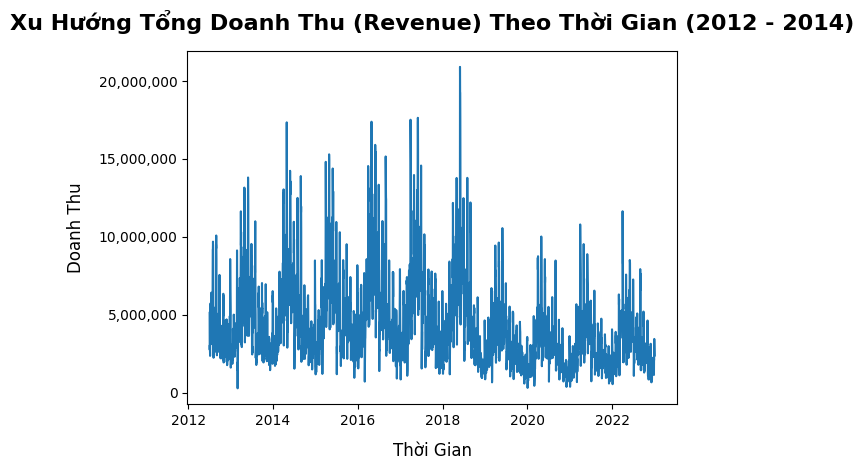

In [26]:
# Thiết lập phong cách đồ thị cho đẹp mắt
# sns.set_theme(style="whitegrid")
# plt.rcParams['figure.figsize'] = (16, 6) # Kích thước biểu đồ ngang

# Vẽ biểu đồ Line Plot
ax = sns.lineplot(x=df_sales.index, y='Revenue', data=df_sales, color='#1f77b4', linewidth=1.5)
plt.title('Xu Hướng Tổng Doanh Thu (Revenue) Theo Thời Gian (2012 - 2014)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Thời Gian', fontsize=12, labelpad=10)
plt.ylabel('Doanh Thu', fontsize=12, labelpad=10)

# Định dạng trục Y để hiển thị số dễ đọc hơn (ví dụ: 10,000,000 thay vì 1e7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

plt.tight_layout()
plt.show()


**Phân rã chuỗi thời gian (Decomposition)**: Tách chuỗi dữ liệu thành 3 thành phần: Trend (Xu hướng), Seasonality (Tính mùa vụ), và Residuals (Độ nhiễu/Các yếu tố ngẫu nhiên).

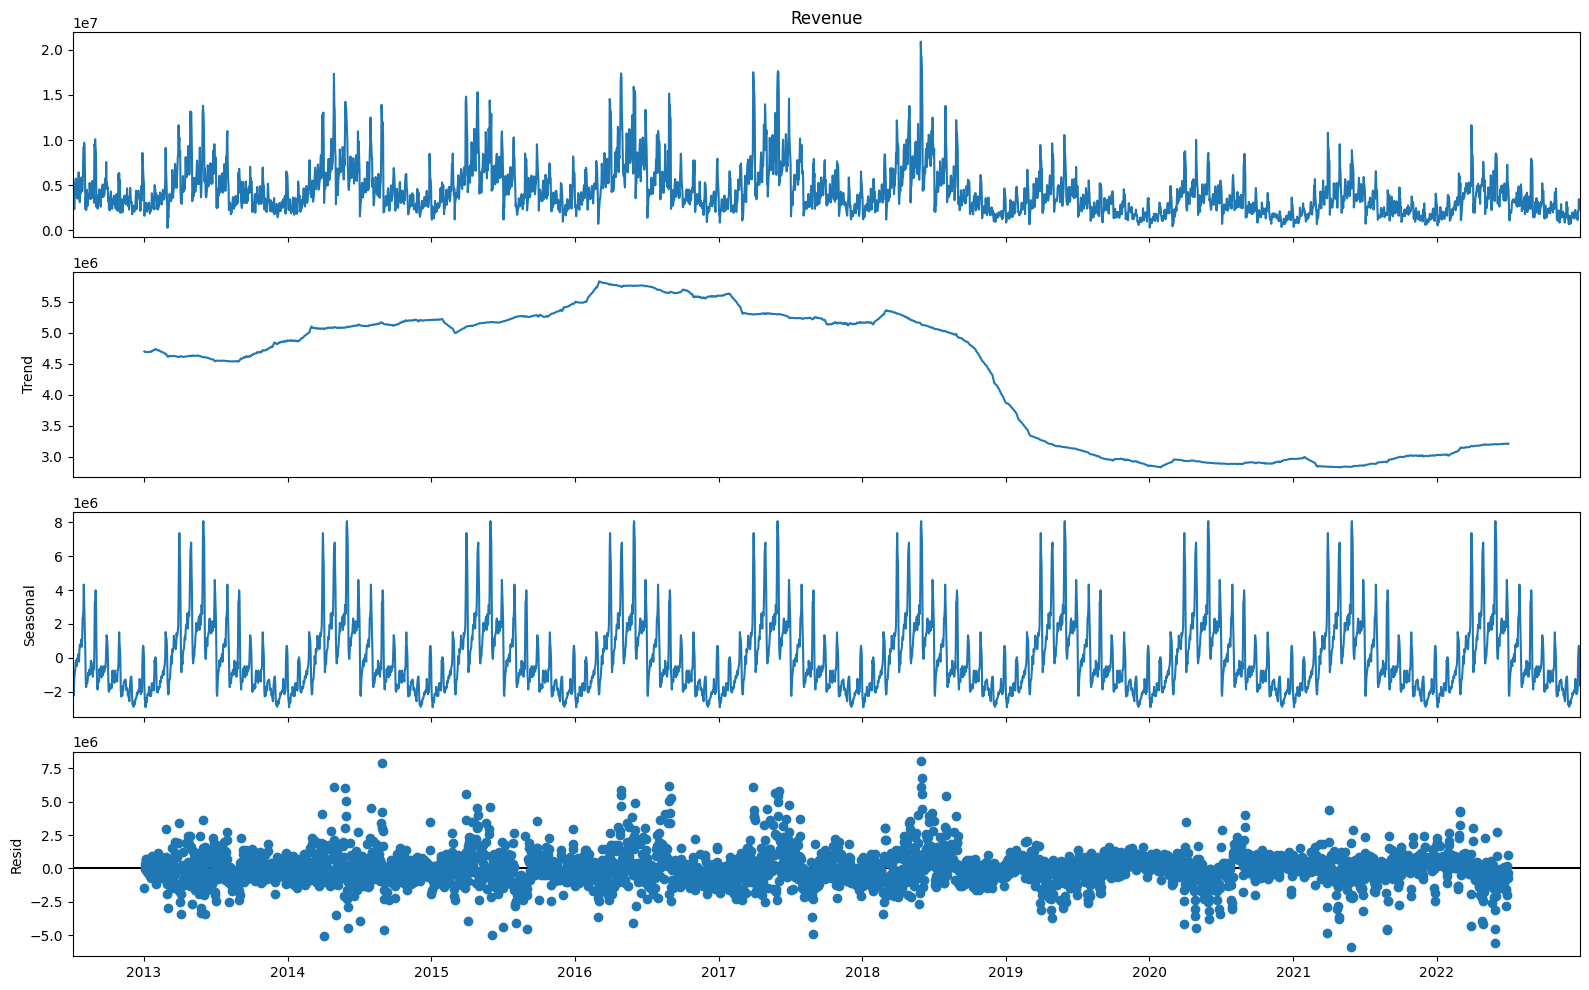

In [27]:
# Vì data có freq theo ngày (daily) nên thử chạy lại shell này với period=7 và period=365
result = seasonal_decompose(df_sales['Revenue'], model='additive', period = 365)  
# (hoặc model='multiplicative' nếu biên độ mùa vụ thay đổi theo mức)

# 3. Vẽ biểu đồ
fig = result.plot()
fig.set_size_inches(16, 10) # Tùy chỉnh kích thước cho dễ nhìn
plt.tight_layout()
plt.show()

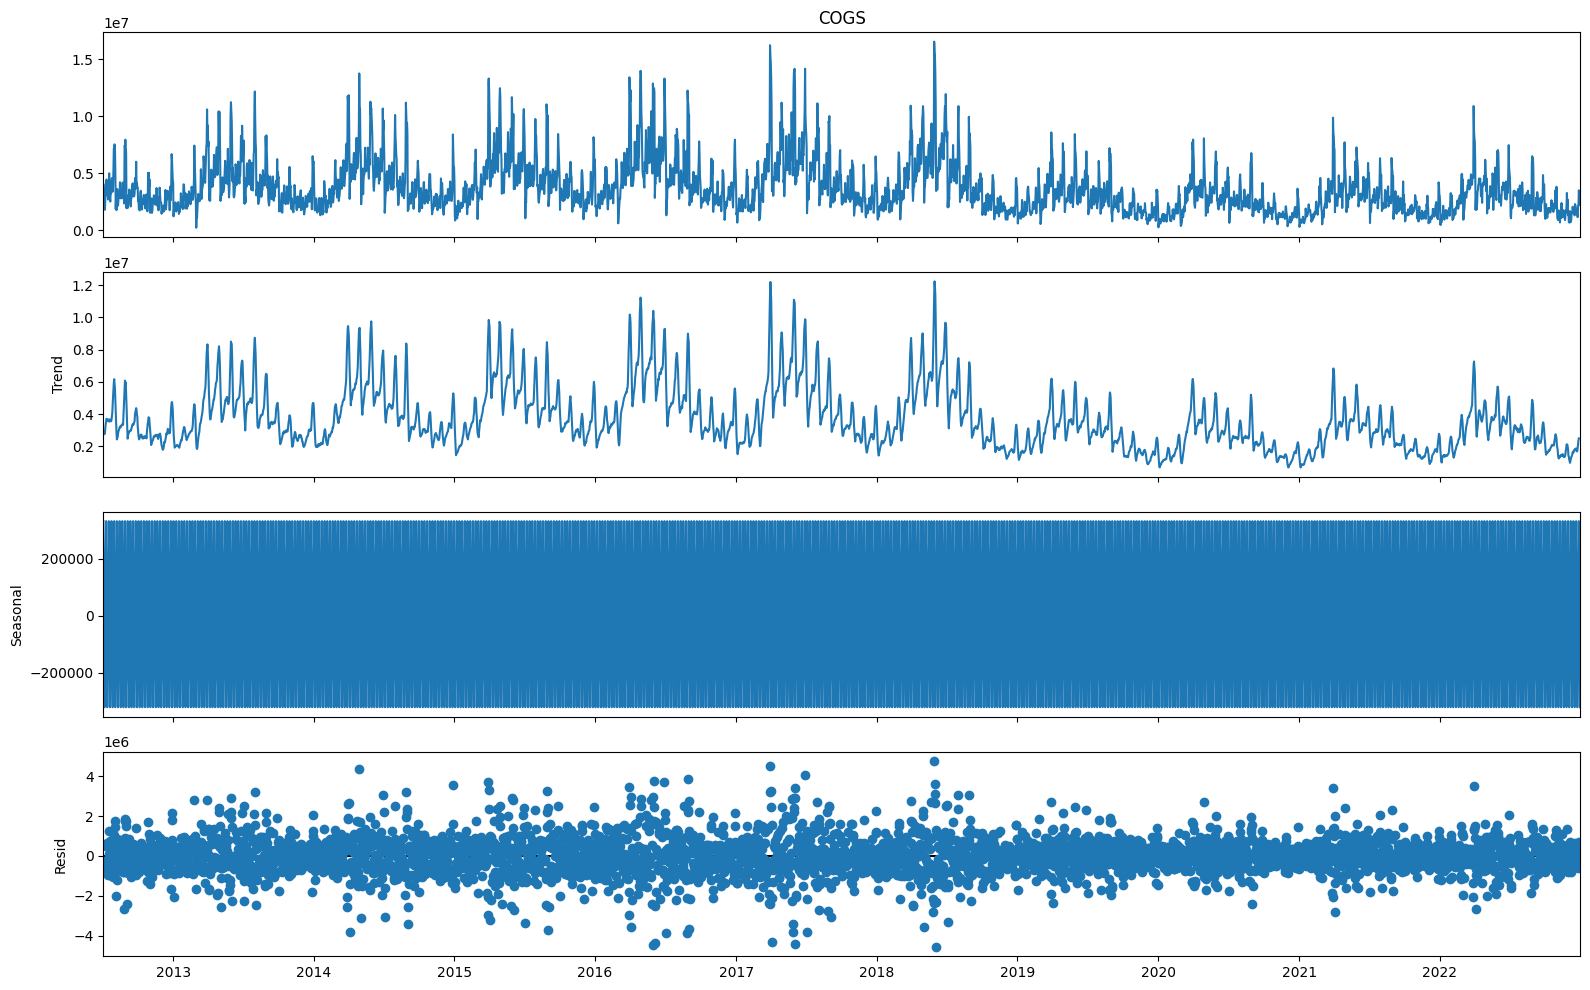

In [28]:
# Cần truyền thêm tham số period. Ở đây giả sử chu kỳ mùa vụ là 7 ngày (1 tuần)
result = seasonal_decompose(df_sales['COGS'], model='additive')  
# (hoặc model='multiplicative' nếu biên độ mùa vụ thay đổi theo mức)

# 3. Vẽ biểu đồ
fig = result.plot()
fig.set_size_inches(16, 10)
plt.tight_layout()
plt.show()


#### Kiểm tra Seasonality theo tuần

In [ ]:
# 1. Lọc dữ liệu 2 tháng bất kỳ (Ví dụ: Tháng 1 và Tháng 2 năm 2013)
start_date = '2013-01-01'
end_date = '2013-02-28'
mask = (df_sales.index >= start_date) & (df_sales.index <= end_date)
df_zoom = df_sales.loc[mask]

# 2. Vẽ biểu đồ
plt.figure(figsize=(16, 6))
ax = sns.lineplot(
    x=df_year.index, y='Revenue', data=df_zoom, 
    marker='o', color='#ff7f0e', linewidth=2, markersize=8
)

# 3. Tinh chỉnh giao diện để quan sát chu kỳ
plt.title(f'Zoom-in Doanh Thu ({start_date} tới {end_date}) - Quan sát chu kỳ Tuần', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# Định dạng trục X: Hiển thị tên Thứ (viết tắt) và Ngày-Tháng (VD: Tue 01-01)
# Đặt interval=2 (hiển thị cách ngày) hoặc interval=1 (hiển thị mỗi ngày) tùy độ rộng màn hình
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%m'))
plt.xticks(rotation=45)

# Định dạng trục Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# Bật lưới dọc (Vertical grid lines) để bạn dễ gióng mắt xem các đỉnh/đáy rơi vào thứ mấy
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.yaxis.grid(True, linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()


ValueError: Length of DatetimeIndex vectors must match length of `data` when both are used, but `data` has length 59 and the vector passed to `x` has length 3833.

<Figure size 1600x600 with 0 Axes>

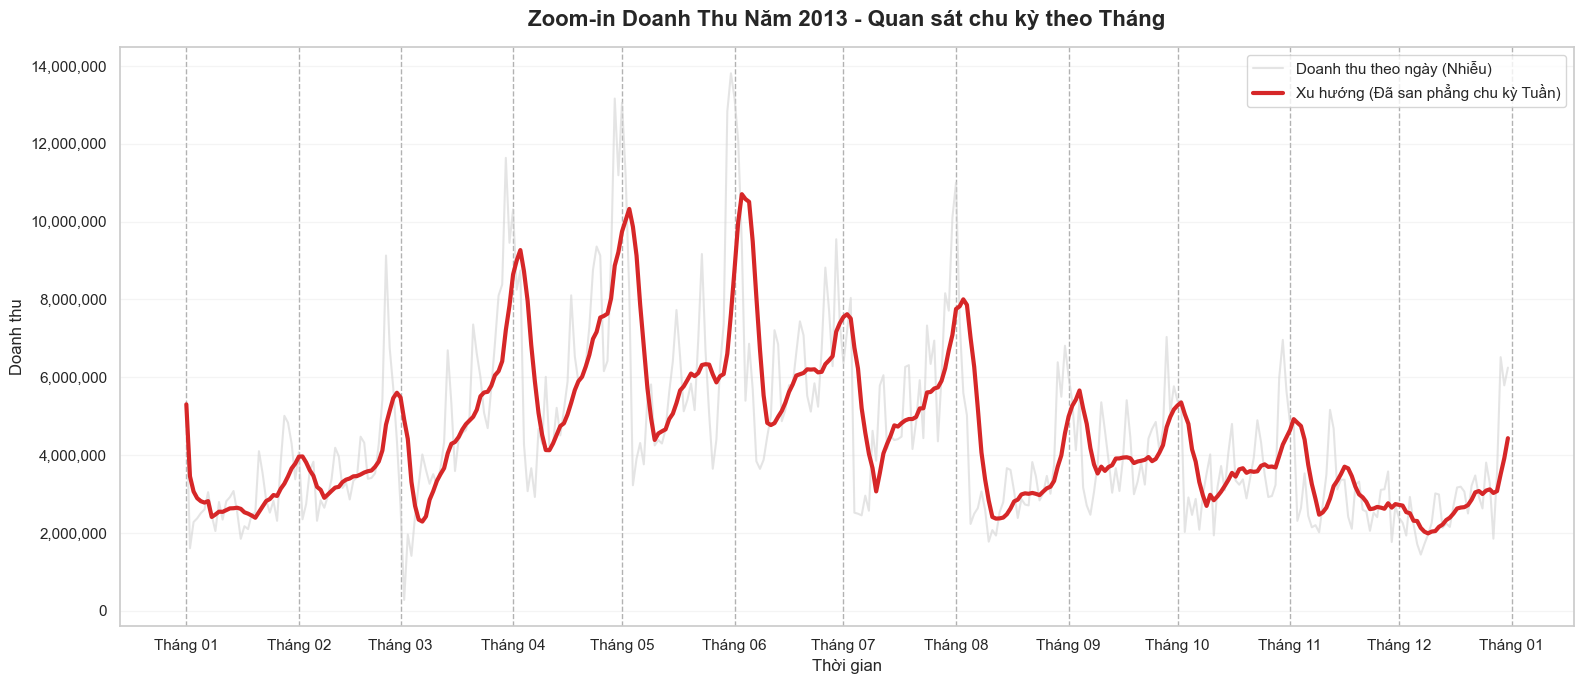

In [ ]:
# 1. Lọc dữ liệu nguyên 1 năm 2013 và đảm bảo dữ liệu đã sắp xếp theo ngày
df_year_2013 = df_sales[df_sales.index.year == 2013].copy()
df_year_2013 = df_year_2013.sort_index()

# 2. Tạo đường Trung bình động 7 ngày (Rolling Average) để khử nhiễu (khử sóng nhỏ của Tuần)
df_year_2013['Revenue_7d_MA'] = df_year_2013['Revenue'].rolling(window=7, min_periods=1).mean()

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 7))

# Đường 1: Doanh thu thực tế từng ngày (màu xám nhạt làm nền)
sns.lineplot(
    x=df_year_2013.index, y='Revenue', data=df_year_2013, 
    color='lightgrey', alpha=0.6, label='Doanh thu theo ngày (Nhiễu)'
)

# Đường 2: Đường xu hướng đã san phẳng (màu đỏ đậm, nét to)
ax = sns.lineplot(
    x=df_year_2013.index, y='Revenue_7d_MA', data=df_year_2013, 
    color='#d62728', linewidth=3, label='Xu hướng (Đã san phẳng chu kỳ Tuần)'
)

# 4. Tinh chỉnh giao diện
plt.title('Zoom-in Doanh Thu Năm 2013 - Quan sát chu kỳ theo Tháng', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# Chia vạch trục X chính xác vào Mùng 1 của mỗi Tháng
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('Tháng %m'))

# Định dạng trục Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# Bật lưới dọc ở mỗi đầu tháng để dễ ngắt đoạn bằng mắt
ax.xaxis.grid(True, linestyle='--', color='black', alpha=0.3)
ax.yaxis.grid(True, linestyle='-', alpha=0.2)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


STL Decomposition:

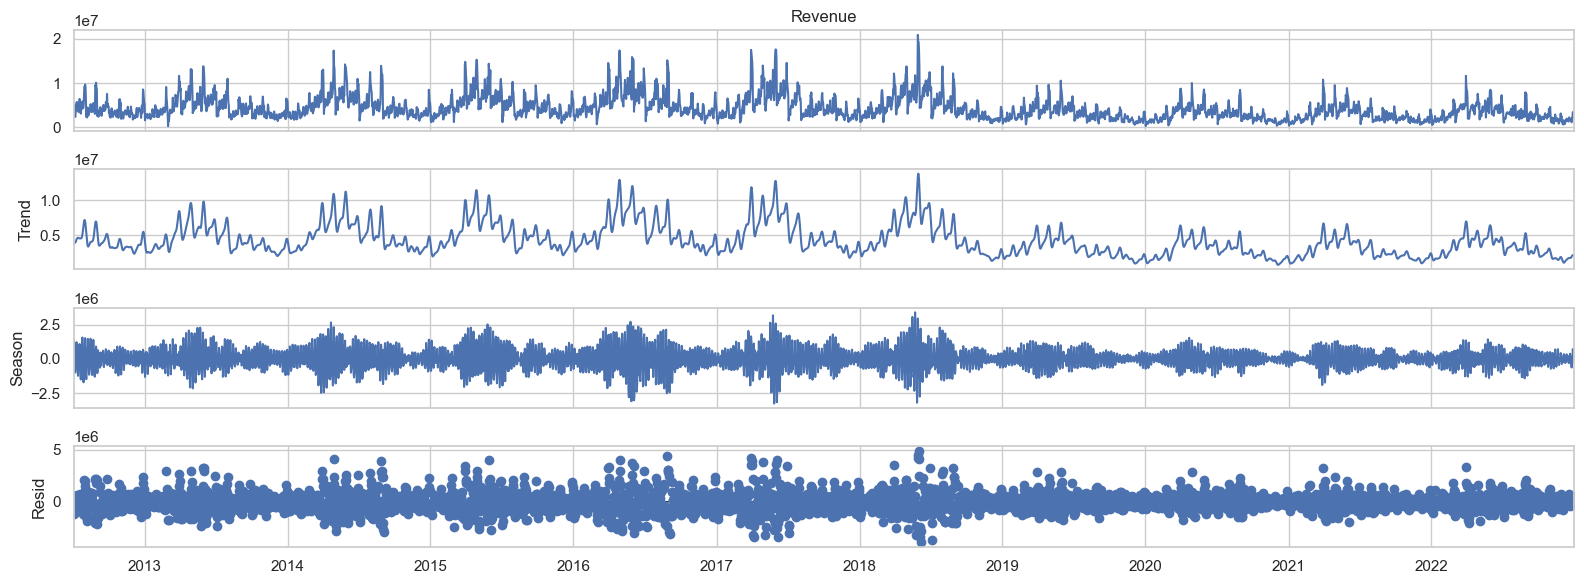

In [ ]:
# ======================
# STL decomposition
# ======================
stl = STL(df_sales['Revenue'], period=7)  # seasonal window (tuning)
result = stl.fit()

# Components
trend = result.trend
seasonal = result.seasonal
resid = result.resid

# Plot
result.plot()
plt.show()

Kiểm tra Seasonality theo ACF/PACF:

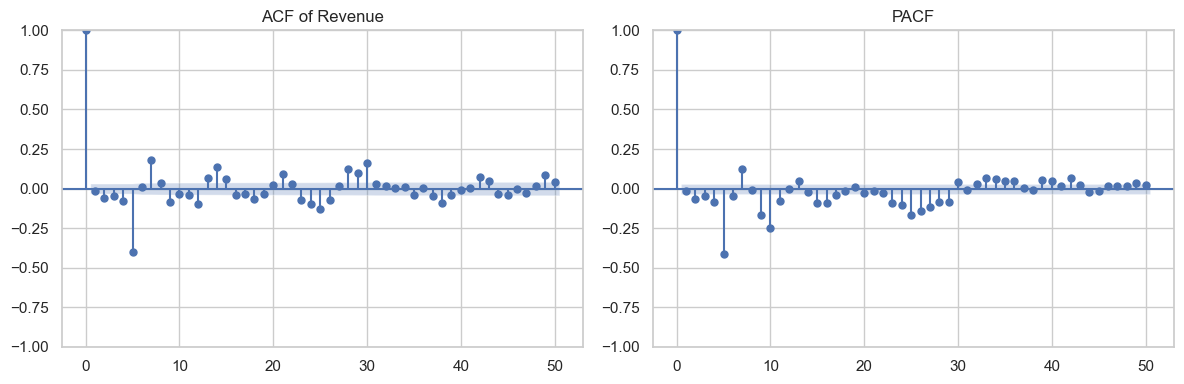

In [ ]:
# Differencing (loại trend) - Chỉ lấy cột Revenue để tránh lỗi với cột Quarter
df_diff = df_sales['Revenue'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df_diff, ax=axes[0], lags=50)
axes[0].set_title('ACF of Revenue')

plot_pacf(df_diff, ax=axes[1], lags=50)
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

- ACF có spike tại các lag = 7, 14, 21, 28,... Mặc dù biên độ của các đỉnh này có xu hướng giảm dần, nhưng sự xuất hiện định kỳ tại các khoảng cách cố định là dấu hiệu điển hình của tính mùa vụ. Ngoài ra, PACF có các giá trị spike tại lag 7 củng cố giả thuyết tính mùa vụ theo tuần
- Dù có spike rõ rệt tại lag = 5 ở cả ACF và PACF, nhưng các dấu hiệu tại lag có bước là 5 về sau lại nằm trong khoảng CI hoặc không có dấu hiệu đồng đều, nên lag = 5 không có ý nghĩa

==> Seasonality = 7

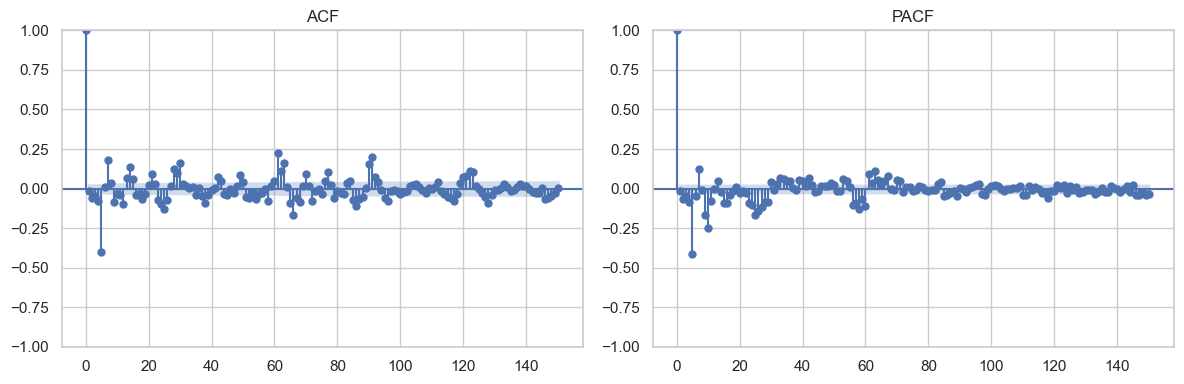

In [ ]:
# Differencing (loại trend) - Chỉ lấy cột Revenue để tránh lỗi với cột Quarter
df_diff = df_sales['Revenue'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df_diff, ax=axes[0], lags=150)
axes[0].set_title('ACF')

plot_pacf(df_diff, ax=axes[1], lags=150)
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

- Các spike xuất hiện đều đặn tại các vị trí lag xấp xỉ 30, 60, 90, 120. Điều này cho thấy sự lặp lại của cấu trúc dữ liệu sau mỗi chu kỳ khoảng $30$ đơn vị thời gian.
- Biểu đồ PACF cũng giúp xác định bậc của thành phần tự hồi quy. Tại các vị trí tương ứng với chu kỳ thời vụ ($lag \approx 30, 60$), ta thấy có các đỉnh âm hoặc dương đáng kể.

==> Seasonality = 30

**KẾT LUẬN**:
- Thông qua plot revenue tổng quan, dễ dàng thấy revenue có seasonality theo năm (365 ngày)
- Bằng hình thức visualize tổng quan và quan sát ACF => Revenue có seasonality theo tuần (7 ngày) và tháng (30 ngày)

### 3.1 Phân tích xu hướng (Trend Analysis)

### 3.2 Phân tích tính mùa vụ và chu kỳ (Seasonality & Cyclical Patterns)

**Phân tích theo Tháng/Quý/Năm:** Nhóm (groupby) tổng hoặc trung bình Revenue theo tháng để xem tháng nào trong năm đem lại doanh thu cao nhất (ví dụ: các tháng cuối năm, mùa sale lễ hội).

In [ ]:
# Tạo các cột thời gian
df_sales['Year'] = df_sales.index.year
df_sales['Month'] = df_sales.index.month
df_sales['Quarter'] = df_sales.index.to_period('Q')

Doanh thu theo tháng:
Month
1     8.032579e+08
2     9.815858e+08
3     1.527737e+09
4     1.959886e+09
5     2.038379e+09
6     1.928133e+09
7     1.575009e+09
8     1.514447e+09
9     1.253282e+09
10    1.126229e+09
11    8.617274e+08
12    8.608032e+08
Name: Revenue, dtype: float64


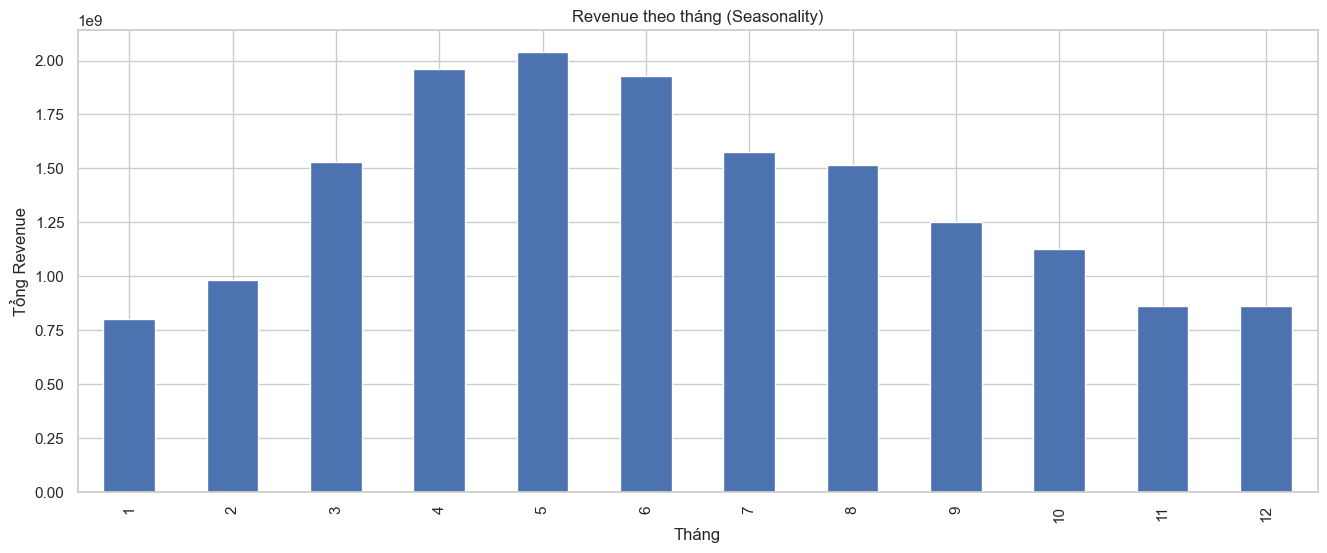

In [ ]:
# ======================
# 1. Phân tích theo THÁNG
# ======================
monthly_revenue = df_sales.groupby('Month')['Revenue'].sum()

print("Doanh thu theo tháng:")
print(monthly_revenue)

# Vẽ biểu đồ
plt.figure()
monthly_revenue.plot(kind='bar')
plt.title("Revenue theo tháng (Seasonality)")
plt.xlabel("Tháng")
plt.ylabel("Tổng Revenue")
plt.show()


Doanh thu theo quý:
Quarter
2012Q3    4.188031e+08
2012Q4    3.226946e+08
2013Q1    3.529265e+08
2013Q2    5.979447e+08
2013Q3    4.095513e+08
2013Q4    2.967470e+08
2014Q1    3.837586e+08
2014Q2    6.850090e+08
2014Q3    4.850453e+08
2014Q4    3.180331e+08
2015Q1    3.815034e+08
2015Q2    7.159155e+08
2015Q3    4.451227e+08
2015Q4    3.473922e+08
2016Q1    4.260457e+08
2016Q2    7.891850e+08
2016Q3    5.513283e+08
2016Q4    3.380817e+08
2017Q1    3.936379e+08
2017Q2    7.598691e+08
2017Q3    4.412357e+08
2017Q4    3.164216e+08
2018Q1    3.713713e+08
2018Q2    7.546762e+08
2018Q3    4.943158e+08
2018Q4    2.297591e+08
2019Q1    2.792273e+08
2019Q2    4.179053e+08
2019Q3    2.641712e+08
2019Q4    1.754977e+08
2020Q1    2.219813e+08
2020Q2    3.833895e+08
2020Q3    2.915925e+08
2020Q4    1.575489e+08
2021Q1    2.258247e+08
2021Q2    4.063572e+08
2021Q3    2.441234e+08
2021Q4    1.667345e+08
2022Q1    2.763045e+08
2022Q2    4.161458e+08
2022Q3    2.974490e+08
2022Q4    1.798495e+08
Freq:

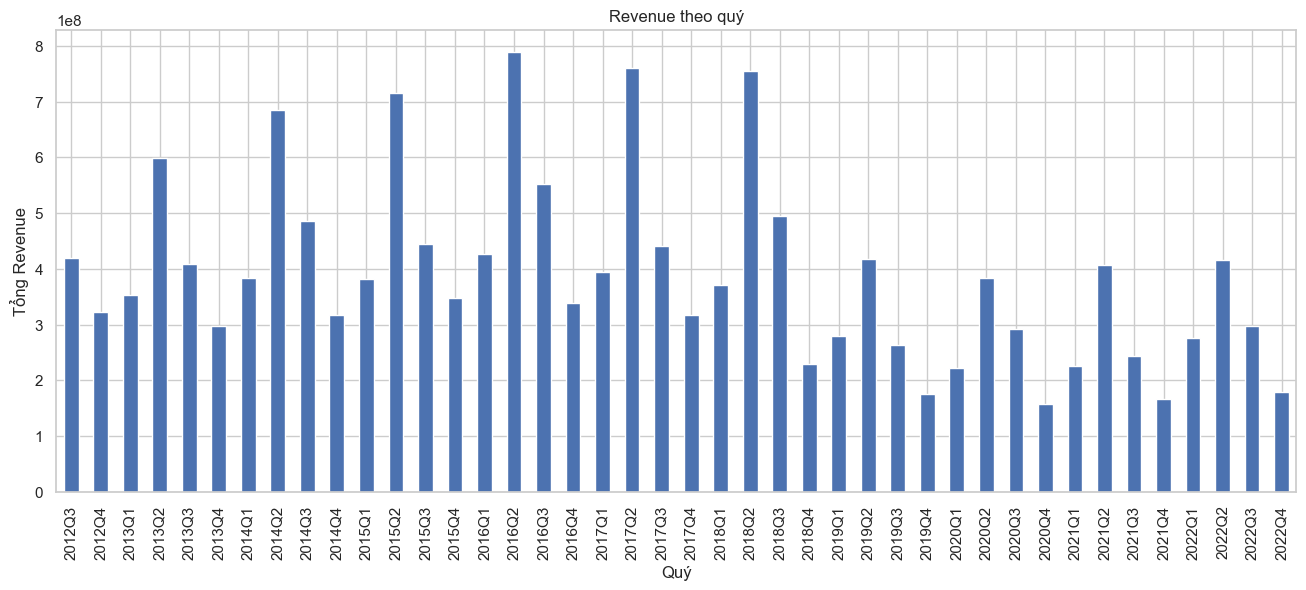

In [ ]:
# ======================
# 2. Phân tích theo QUÝ
# ======================
quarterly_revenue = df_sales.groupby('Quarter')['Revenue'].sum()

print("\nDoanh thu theo quý:")
print(quarterly_revenue)

plt.figure()
quarterly_revenue.plot(kind='bar')
plt.title("Revenue theo quý")
plt.xlabel("Quý")
plt.ylabel("Tổng Revenue")
plt.show()

In [ ]:
# ======================
# 3. Phân tích theo NĂM
# ======================
yearly_revenue = df.groupby('year')['revenue'].sum()

print("\nDoanh thu theo năm:")
print(yearly_revenue)

plt.figure()
yearly_revenue.plot(kind='bar')
plt.title("Revenue theo năm")
plt.xlabel("Năm")
plt.ylabel("Tổng Revenue")
plt.show()

# ======================
# 4. So sánh seasonality giữa các năm
# ======================
pivot_table = df.pivot_table(
    values='revenue',
    index='month',
    columns='year',
    aggfunc='sum'
)

print("\nPivot table (month vs year):")
print(pivot_table)

plt.figure()
pivot_table.plot()
plt.title("Seasonality theo tháng qua các năm")
plt.xlabel("Tháng")
plt.ylabel("Revenue")
plt.show()

NameError: name 'df' is not defined

**Phân tích theo Ngày trong tuần (Day of week):** Doanh thu có chênh lệch rõ rệt giữa Ngày cuối tuần (T7, CN) so với Ngày thường (T2-T6) không?

**Phân tích theo Ngày trong tháng (Day of month):** Xem xét doanh thu có thường xuyên bật tăng vào những ngày đầu tháng (người dân nhận lương) hoặc các dịp sale ngày đôi (như 7/7, 8/8) không?

### 3.3 Phân tích Phân phối & Ngoại lai (Distribution & Outliers)

**Biểu đồ Histogram & Boxplot:** Xem phân phối của Revenue và COGS có bị lệch chuẩn (skewness) hay không. Đặc biệt là Boxplot để xác định các ngày có mức doanh thu "bất thường" (Outliers).

**Deep dive vào Outliers:** Lọc ra Top 1% các ngày có doanh thu cao nhất/thấp nhất và phân tích xem ngày đó có sự kiện gì (ngày lễ, Black Friday, chiến dịch khuyến mãi lớn,...).

### 3.4 Phân tích Lợi nhuận (Profit Margin)

Từ Revenue và COGS, tính ra một biến mới: `Profit = Revenue - COGS` hoặc Biên độ lợi nhuận `Margin = (Revenue - COGS) / Revenue.`

Vẽ biểu đồ tương quan (Scatter plot) giữa `COGS` và `Revenue` hoặc theo dõi sự biến động của `Margin` theo thời gian xem tỷ suất lợi nhuận có ổn định không hay đang bị thu hẹp dần.

### 3.5 Kiểm tra tính Tự tương quan (Autocorrelation)

**Đồ thị ACF và PACF:** Giúp trả lời câu hỏi: "Doanh thu của ngày hôm nay tương quan mạnh nhất với doanh thu của bao nhiêu ngày trước đó (lag 1, lag 7, lag 30)?". Đây là cơ sở cốt lõi để chọn lag cho Feature Engineering.

---
**Kết luận:**

---
**Notebooks tiếp theo:** [04_BASELINE_MODEL_.ipynb](04_BASELINE_MODEL_.ipynb) - Lựa chọn đặc trưng